# Anomaly detection with autoencoders

The goal of this activity is to use a convolutional encoder to do unsupervised anomaly detection on images. An autoencoder can be trained on a set of images (say all of the 'animal' classes from CIFAR-10), and then used to detect images which do not belong in this 'class' e.g. boats by looking at the reconstruction error. Images which are very different from the training set will not be represented well in latent space and have lower reconstruction quality as a result.

Most of the up front data wrangling has been done for you, your job is to adapt the autoencoder architecture from the compression and denoising notebooks to anomaly detection.

## 1. Notebook setup

### 1.1. Imports

In [ ]:
import json
import os
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, losses, metrics

# Reproducibility
tf.random.set_seed(315)
np.random.seed(315)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.16.1
GPU available: True


### 1.2. GPU configuration

In [46]:
# Select GPU and configure memory growth to avoid allocation issues
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Restrict to GPU 0 only
        tf.config.set_visible_devices(gpus[1], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[1], True)

        print('Using GPU 0 with memory growth enabled')

    except RuntimeError as e:
        print(f'GPU configuration error: {e}')

Using GPU 0 with memory growth enabled


### 1.3. Environment configuration

In [47]:
# Environment variables
load_dotenv(project_root / '.env')  # For HuggingFace upload (HF_TOKEN, HF_REPO_ID)

# Paths
data_path    = project_root / 'data'
model_path   = project_root / 'models' / 'anomaly_ae.keras'
history_path = project_root / 'logs' / 'anomaly' / 'history.json'
log_dir      = project_root / 'logs' / 'anomaly'

log_dir.mkdir(parents=True, exist_ok=True)

print(f'Data will be cached to: {data_path}')
print(f'Model will be saved to: {model_path}')
print(f'History will be saved to: {history_path}')
print(f'Log directory: {log_dir}')

Data will be cached to: /workspaces/autoencoders/data
Model will be saved to: /workspaces/autoencoders/models/anomaly_ae.keras
History will be saved to: /workspaces/autoencoders/logs/anomaly/history.json
Log directory: /workspaces/autoencoders/logs/anomaly


### 1.4. Hyperparameters

In [48]:
train_model  = True  # Set False to skip training and load saved model
upload_model = True  # Set False to skip upload 
image_size   = 32    # Image input size (32x32)
val_split    = 0.1
batch_size   = 128
epochs       = 5
verbose      = 1

early_stopping_patience = 3

cifar10_classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]

## 2. Data preparation

### 2.1. Download and extract CIFAR10

In [49]:
# Download and extract
archive_path = tf.keras.utils.get_file(
    fname='cifar-10-python.tar.gz',
    origin='https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz',
    cache_dir=data_path,
    extract=True,
    archive_format='auto'
)

### 2.2. Load CIFAR-10 from disk

In [50]:
def load_cifar_batch(file_path):
    '''Helper function to load a single CIFAR-10 batch from disk.
    Returns the data and labels as numpy arrays.
    '''

    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    
    data = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])

    return data, labels

In [51]:
# Load the dataset
data_dir = os.path.join(os.path.dirname(archive_path), 'cifar-10-batches-py')

# Load training splits
x_train_list, y_train_list = [], []

for i in range(1, 6):
    x_b, y_b = load_cifar_batch(os.path.join(data_dir, f'data_batch_{i}'))
    x_train_list.append(x_b)
    y_train_list.append(y_b)

x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)

# Load test split
x_test, y_test = load_cifar_batch(os.path.join(data_dir, 'test_batch'))

print(f'Training images shape: {x_train.shape}, Training labels shape: {y_train.shape}')
print(f'Test images shape: {x_test.shape}, Test labels shape: {y_test.shape}')

Training images shape: (50000, 32, 32, 3), Training labels shape: (50000,)
Test images shape: (10000, 32, 32, 3), Test labels shape: (10000,)


### 2.3. Inspect

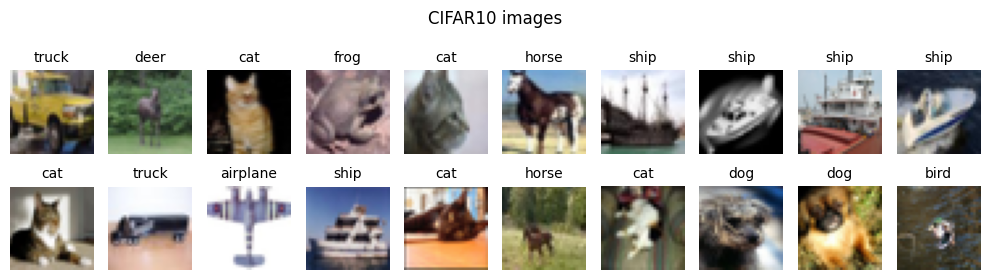

In [52]:
# Randomly select 10 indices from the training set
sample_indices = np.random.choice(len(x_train), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('CIFAR10 images')

for idx, ax in zip(sample_indices, axes):
  img = x_train[idx]  # Values are in [0, 1]
  label_idx = y_train[idx][0] if y_train.ndim > 1 else y_train[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

### 2.4. Select only 'animal' images for training set

In [53]:
# Target animal classes: cat (3), deer (4), dog (5), horse (7)
animal_classes = [3, 4, 5, 7]

# Flatten labels if shape is (N, 1)
y_flat = y_train.flatten() if y_train.ndim > 1 else y_train

# Create boolean mask
mask = np.isin(y_flat, animal_classes)

# Filter and normalize
x_train_normals = x_train[mask].astype('float32') / 255.0
y_train_normals = y_flat[mask]

print(f"Filtered training normals shape: {x_train_normals.shape}")
print(f"Unique classes present: {np.unique(y_train_normals)}")

Filtered training normals shape: (20000, 32, 32, 3)
Unique classes present: [3 4 5 7]


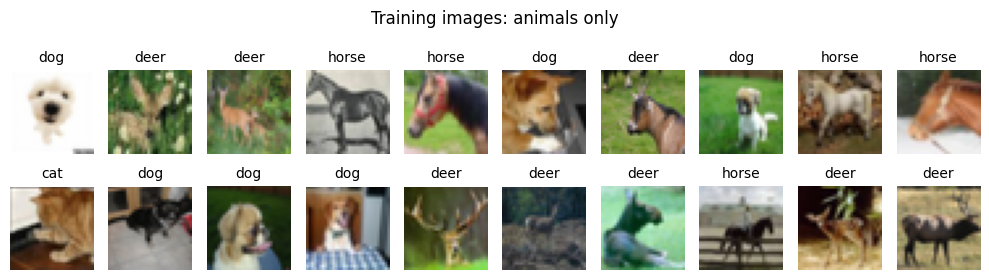

In [54]:
# Randomly select 10 indices from the training set
sample_indices = np.random.choice(len(x_train_normals), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('Training images: animals only')

for idx, ax in zip(sample_indices, axes):
  img = x_train_normals[idx]  # Values are in [0, 1]
  label_idx = y_train_normals[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

### 2.5. Select 'animal' + car and truck ('anomaly') images for test set

In [55]:
# Target test classes: 4 normals (3, 4, 5, 7) + 2 anomalies/vehicles (1, 9)
target_test_classes = [3, 4, 5, 7, 1, 9]
normal_classes = {3, 4, 5, 7}

y_test_flat = y_test.flatten() if y_test.ndim > 1 else y_test
test_mask = np.isin(y_test_flat, target_test_classes)

# Filter and scale test subset
x_test_subset = x_test[test_mask].astype("float32") / 255.0
y_test_subset = y_test_flat[test_mask]

# Ground-truth binary labels: 0 = normal (animal), 1 = anomaly (vehicle)
is_normal = np.isin(y_test_subset, list(normal_classes))
y_test_binary = (~is_normal).astype(int)

print(f"Filtered test subset shape: {x_test_subset.shape}")
print(f"Normal animals: {np.sum(y_test_binary == 0)}")
print(f"Vehicle anomalies (auto/truck): {np.sum(y_test_binary == 1)}")

Filtered test subset shape: (6000, 32, 32, 3)
Normal animals: 4000
Vehicle anomalies (auto/truck): 2000


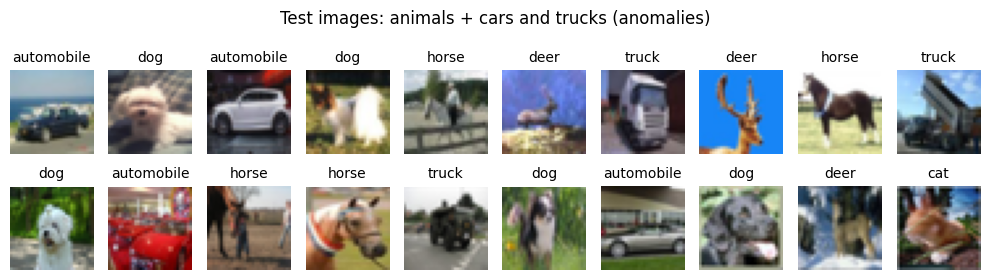

In [56]:
# Randomly select 10 indices from the test set
sample_indices = np.random.choice(len(x_test_subset), size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(10, 3))
axes = axes.flatten()

fig.suptitle('Test images: animals + cars and trucks (anomalies)')

for idx, ax in zip(sample_indices, axes):
  img = x_test_subset[idx]  # Values are in [0, 1]
  label_idx = y_test_subset[idx]

  ax.imshow(img)
  ax.set_title(cifar10_classes[label_idx], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Model definition

# Lab Activity: Building a Convolutional Autoencoder for Anomaly Detection

## 1. Model Architecture: Convolutional Autoencoder
**Task:** Build a Keras functional or sequential model that compresses `(32, 32, 3)` images into a lower-dimensional latent representation and reconstructs them back to `(32, 32, 3)`.
* **Hint (Encoder):** Stack 2–3 `Conv2D` layers with `strides=2` and `'same'` padding to downsample spatial dimensions (e.g., $32 \rightarrow 16 \rightarrow 8 \rightarrow 4$). Use `'relu'` activation.
* **Hint (Decoder):** Mirror the encoder using `Conv2DTranspose` (or `UpSampling2D` + `Conv2D`) with `strides=2` to scale back up to $32 \times 32$.
* **Hint (Output Layer):** Since your pixel values are normalized to $[0, 1]$, use `'sigmoid'` activation on the final convolutional layer. Compile with optimizer `'adam'` and loss `'mse'`.

In [ ]:
def build_conv_autoencoder(input_shape=(32, 32, 3)):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder (32x32x3 -> 4x4x128)
    # Your code here...
    
    # Decoder (4x4x128 -> 32x32x3)
    # Your code here...
    
    return models.Model(inputs, decoded, name='conv_ae')


autoencoder = build_conv_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

## 4. Train

In [ ]:
%%time

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=early_stopping_patience,
        restore_best_weights=True,
        verbose=verbose
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(model_path).replace('.keras', '_weights.weights.h5'),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=verbose
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=0
    ),
]

history = autoencoder.fit(
    x_train_normals, x_train_normals,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_split,
    shuffle=True,
    callbacks=callbacks
)

print()

## 5. Learning curves

In [ ]:
if history is not None:

    # Handle both keras History object and loaded dict
    history_dict = history.history if hasattr(history, 'history') else history

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.set_title('Training History')
    ax.plot(history_dict['loss'], label='Train Loss')
    ax.plot(history_dict['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. Anomaly detection

### 6.1. Set detection threshold on reconstruction error

**Task:** Establish a quantitative reconstruction error threshold using your training normals.
* **Hint 1:** Run inference on your training normal set (`autoencoder.predict(x_train_normals)`).
* **Hint 2:** Compute per-sample Mean Squared Error across height, width, and channels: `np.mean(np.square(images - predictions), axis=(1, 2, 3))`.
* **Hint 3:** Set a statistical threshold using distribution parameters: $\text{threshold} = \mu_{\text{train}} + k \cdot \sigma_{\text{train}}$ (try $k=3$).

In [ ]:
# Compute reconstruction error on training normals to set threshold
train_preds = autoencoder.predict(x_train_normals, batch_size=256)

# Get MSE for each reconstruction
# Your code here...

# Determine a 'threshold' where high reconstruction error indicates an anomaly
# Your code here...

plt.hist(train_mse, bins=50, color='black')
plt.axvline(threshold, color='r', linestyle='--')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('Training Reconstruction Error Distribution')
plt.show()

### 6.2. Test set evaluation

**Task:** Evaluate anomaly detection performance on your mixed test subset (`x_test_subset`, where $0=\text{normal animal}$, $1=\text{vehicle anomaly}$).
* **Hint 1:** Compute reconstruction MSE on `x_test_subset`, then apply your threshold: `predictions = (test_mse > threshold).astype(int)`.
* **Hint 2:** Calculate overall classification accuracy and compare error distributions between normal animals and vehicle anomalies.
* **Bonus / Discussion Question:** If accuracy on vehicles is lower than expected, is the autoencoder suffering from the **"copy-blur" trap** (reconstructing OOD data too well due to high capacity)? How might you adjust latent dimensions or loss functions?

In [ ]:
# Your code here...

accuracy = np.mean(predictions == y_test_subset)
print(f"Test Detection Accuracy: {accuracy:.4f}")